In [ ]:
"""
PyTorch implementation: Grouped EKF-SSR on voiced speech signal.
For subsection: "Grouped summing array for nonstationary signals"

Array structure (M=2 groups, N=31 total):
  Group 1: N1=15 quantizers, threshold theta1 = -0.5  (fixed)
  Group 2: N2=16 quantizers, threshold theta2 = +0.5  (fixed)

Each group output:
  phi_{m,k} = (1/Nm) * sum_n sign(x_k + sigma_k*xi_n - theta_m)

Reconstruction:
  x_hat_k = w1_k * phi_{1,k} + w2_k * phi_{2,k}

EKF estimates sigma_k online; w1_k, w2_k via 2D RLS.

Comparison:
  (1) Grouped EKF-SSR (proposed, sigma_0=0.5)
  (2) Grouped fixed sigma=sigma* (oracle KDE)
  (3) Single group N=31, theta=0, EKF-SSR (baseline)

Two theoretical bounds: Gaussian f_x and empirical KDE.

Run in Jupyter:  %matplotlib inline  (first cell)
"""

import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
from scipy.signal import lfilter
from scipy.stats import gaussian_kde
from scipy.special import erf
import scienceplots

# ── 绘图风格 ──────────────────────────────────────────
plt.style.use(['science', 'ieee'])
mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 10,
    'axes.labelsize'    : 10,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 100,      # Jupyter 显示
    'axes.unicode_minus': False,
})

def lighten_color(color, amount=0.25):
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1-amount*(1-c[1]), c[2])

# ════════════════════════════════════════════════════════
# 1.  合成语音信号（元音 /a/，男声 F0=120 Hz）
# ════════════════════════════════════════════════════════
torch.manual_seed(2024)
np.random.seed(2024)

fs       = 8000     # 采样率 Hz
duration = 3.0      # 总时长 s
t_arr    = np.arange(0, duration, 1/fs)
Nx_total = len(t_arr)

# 谐波声源
F0 = 120;  harmonics = 25
voice_src = np.zeros(Nx_total)
for k in range(1, harmonics+1):
    voice_src += (1.0/k) * np.sin(2*np.pi*k*F0*t_arr)

# 共振峰滤波（/a/: F1=800 Hz, F2=1200 Hz, F3=2500 Hz）
def formant_filter(sig, fc, bw):
    r     = np.exp(-np.pi*bw/fs)
    theta = 2*np.pi*fc/fs
    return lfilter([1-r], [1, -2*r*np.cos(theta), r**2], sig)

speech = formant_filter(voice_src, 800,  80)
speech = formant_filter(speech,    1200, 100)
speech = formant_filter(speech,    2500, 150)
speech = speech / np.max(np.abs(speech)) * 0.9   # 归一化

sigma_x = float(np.std(speech))
kurt    = float(np.mean((speech - speech.mean())**4) / sigma_x**4 - 3)
print(f"Speech: {Nx_total} samples, fs={fs} Hz")
print(f"  sigma_x={sigma_x:.4f}, excess kurtosis={kurt:.2f} "
      f"(Gaussian=0, Laplace≈3)")

# ════════════════════════════════════════════════════════
# 2.  分组阵列参数（M=2）
# ════════════════════════════════════════════════════════
#  Group 1: N1=15 quantizers, theta1=-0.5
#  Group 2: N2=16 quantizers, theta2=+0.5
N1, theta1 = 15, -0.25
N2, theta2 = 16, +0.25
N_total    = N1 + N2      # = 31

# h_bar for each group (Gaussian dither):
#   h_bar_m(x, sigma) = E[sign(x + sigma*xi - theta_m)]
#                     = erf((x - theta_m) / (sigma*sqrt(2)))
def h_bar_m(x, sigma, theta):
    return erf((x - theta) / (sigma * np.sqrt(2)))

def h_bar_m_deriv_sigma(x, sigma, theta):
    """d/d_sigma of h_bar_m  =  -2/sqrt(pi) * ((x-theta)/sigma^2)
       * exp(-((x-theta)/sigma)^2 / 2) / sqrt(2)"""
    u = (x - theta) / (sigma * np.sqrt(2))
    return -np.sqrt(2/np.pi) * (x-theta) / sigma**2 * np.exp(-u**2)

# ════════════════════════════════════════════════════════
# 3.  理论最优值（分组阵列，两种 f_x 假设）
# ════════════════════════════════════════════════════════
def compute_theory_grouped(fx_fn, N1, theta1, N2, theta2, sx):
    """
    Grouped array MSE:
      MSE = sigma_x^2 - [p1, p2] R^{-1} [p1, p2]^T
    where R = [[R11, R12],[R12, R22]],
      p_m   = E_x[x * h_bar_m(x, sigma)]
      R_mm  = N_m * E_x[h_bar_m^2]  +  (extra from cross terms)
    For M=2, use the closed-form 2x2 inverse.
    """
    def mse_fn(sigma):
        p1  = quad(lambda x: x*h_bar_m(x,sigma,theta1)*fx_fn(x),
                   -6*sx, 6*sx)[0]
        p2  = quad(lambda x: x*h_bar_m(x,sigma,theta2)*fx_fn(x),
                   -6*sx, 6*sx)[0]
        # within-group auto-correlation
        psi11 = quad(lambda x: h_bar_m(x,sigma,theta1)**2*fx_fn(x),
                     -6*sx, 6*sx)[0]
        psi22 = quad(lambda x: h_bar_m(x,sigma,theta2)**2*fx_fn(x),
                     -6*sx, 6*sx)[0]
        # cross-group correlation
        psi12 = quad(lambda x: h_bar_m(x,sigma,theta1)
                               *h_bar_m(x,sigma,theta2)*fx_fn(x),
                     -6*sx, 6*sx)[0]
        # R matrix elements (identical quantizers within each group)
        R11 = 1 + (N1-1)*psi11   # = N1*(auto) + N1*(N1-1)*(cross within)
        R22 = 1 + (N2-1)*psi22
        R12 = N1*N2*psi12 / (N1*N2)   # cross between groups
        # simplified: treat phi_m = (1/Nm)*sum as having
        # E[phi_m^2] = (1/Nm + (1-1/Nm)*psi_mm)
        # Use direct 2x2 Wiener-Hopf:
        # MSE = sx^2 - [p1,p2] * R_phi^{-1} * [p1,p2]^T
        # R_phi[m,m] = E[phi_m^2] , R_phi[1,2]=E[phi1*phi2]
        Rp11 = 1.0/N1 + (1-1.0/N1)*psi11
        Rp22 = 1.0/N2 + (1-1.0/N2)*psi22
        Rp12 = psi12
        det  = Rp11*Rp22 - Rp12**2
        if abs(det) < 1e-12:
            return sx**2
        inv11 = Rp22/det; inv22 = Rp11/det; inv12 = -Rp12/det
        return sx**2 - (p1**2*inv11 + 2*p1*p2*inv12 + p2**2*inv22)

    res = minimize_scalar(mse_fn, bounds=(0.01, 5*sx), method='bounded')
    return res.x, mse_fn(res.x)

print("Computing theoretical bounds (grouped array)...")
# Gaussian f_x
sx = sigma_x
fx_gauss = lambda x: np.exp(-x**2/(2*sx**2))/np.sqrt(2*np.pi*sx**2)
sigma_th_G, mse_th_G = compute_theory_grouped(
    fx_gauss, N1, theta1, N2, theta2, sx)

# Empirical KDE f_x
kde = gaussian_kde(speech, bw_method='silverman')
fx_kde = lambda x: float(kde(x))
sigma_th_E, mse_th_E = compute_theory_grouped(
    fx_kde, N1, theta1, N2, theta2, sx)

sp_pwr_all = np.mean(speech**2)
snr_th_G = 10*np.log10(sp_pwr_all / mse_th_G)
snr_th_E = 10*np.log10(sp_pwr_all / mse_th_E)
print(f"  Gaussian f_x: σ*={sigma_th_G:.4f}, "
      f"MSE={mse_th_G:.5f}, SNR={snr_th_G:.2f} dB")
print(f"  KDE f_x:      σ*={sigma_th_E:.4f}, "
      f"MSE={mse_th_E:.5f}, SNR={snr_th_E:.2f} dB")

# ════════════════════════════════════════════════════════
# 4.  分组 EKF-SSR（PyTorch 内层循环）
# ════════════════════════════════════════════════════════
Q_sigma   = 1e-3
R_sigma   = 1.0
P0_sigma  = 2.0
delta_rls = 0.1
window    = 100     # ~12 ms

def gauss_pdf_t(u):
    return torch.exp(-0.5*u**2) / (2*torch.pi)**0.5

def run_grouped_ekf_ssr(x_np, sigma_init, seed=2024):
    """
    Grouped EKF-SSR:
      - phi1_k = mean(sign(x_k + sigma*xi - theta1)),  xi ~ N(0,1), size N1
      - phi2_k = mean(sign(x_k + sigma*xi - theta2)),  xi ~ N(0,1), size N2
      - x_hat_k = w1*phi1_k + w2*phi2_k
      - 2D RLS updates w1, w2
      - EKF updates sigma via scalar Jacobian H_k = dE[x_hat]/d_sigma
    """
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)

    th1 = torch.tensor(theta1, dtype=torch.float32)
    th2 = torch.tensor(theta2, dtype=torch.float32)

    # 2D RLS
    w   = torch.tensor([1.0, 1.0])          # [w1, w2]
    P_w = torch.eye(2) * 10.0               # 2x2 covariance

    sigma_k = torch.tensor(float(sigma_init))
    P_sigma = torch.tensor(float(P0_sigma))

    sigma_hist = np.zeros(T)
    w1_hist    = np.zeros(T)
    w2_hist    = np.zeros(T)
    mse_inst   = np.zeros(T)
    xhat_hist  = np.zeros(T)

    for k in range(T):
        x_k = x_t[k]

        torch.manual_seed(seed + 3*k)
        xi1   = torch.randn(N1)
        xi2   = torch.randn(N2)

        # 分组量化器输出
        phi1  = torch.sign(x_k + sigma_k*xi1 - th1).mean()
        phi2  = torch.sign(x_k + sigma_k*xi2 - th2).mean()
        phi_k = torch.stack([phi1, phi2])    # [2]

        # 重建与误差
        x_hat = torch.dot(w, phi_k)
        e_k   = x_k - x_hat

        # 2D RLS 权重更新
        P_phi  = P_w @ phi_k                 # [2]
        denom  = phi_k @ P_phi + delta_rls
        g_rls  = P_phi / denom               # [2] Kalman gain
        w      = w + g_rls * e_k
        P_w    = P_w - torch.outer(g_rls, P_phi)

        # EKF Jacobian: H_k = d(x_hat)/d(sigma)
        #   = w1 * d(phi1)/d(sigma) + w2 * d(phi2)/d(sigma)
        #   d(phi_m)/d(sigma) ≈ -(x_k - theta_m)/sigma^2 * f_xi(u_m)
        s_safe = sigma_k.clamp(min=0.01)
        u1 = (x_k - th1) / s_safe
        u2 = (x_k - th2) / s_safe
        dh1 = -(x_k - th1) / s_safe**2 * gauss_pdf_t(u1)
        dh2 = -(x_k - th2) / s_safe**2 * gauss_pdf_t(u2)
        H_k = w[0]*dh1 + w[1]*dh2           # scalar

        # EKF sigma 更新
        P_pred  = P_sigma + Q_sigma
        K_sigma = P_pred * H_k / (H_k**2 * P_pred + R_sigma)
        step    = (K_sigma * e_k).clamp(-0.3, 0.3)

        sigma_k = (sigma_k + step).clamp(0.01, 5.0)
        P_sigma = (1 - K_sigma * H_k) * P_pred

        sigma_hist[k] = sigma_k.item()
        w1_hist[k]    = w[0].item()
        w2_hist[k]    = w[1].item()
        mse_inst[k]   = e_k.item()**2
        xhat_hist[k]  = x_hat.item()

    return sigma_hist, w1_hist, w2_hist, mse_inst, xhat_hist


def run_grouped_fixed(x_np, sigma_fixed, seed=2024):
    """Grouped array, fixed sigma, 2D RLS weights."""
    torch.manual_seed(seed)
    T   = len(x_np)
    x_t = torch.tensor(x_np, dtype=torch.float32)
    th1 = torch.tensor(theta1, dtype=torch.float32)
    th2 = torch.tensor(theta2, dtype=torch.float32)
    w   = torch.tensor([1.0, 1.0])
    P_w = torch.eye(2) * 10.0
    sf  = torch.tensor(float(sigma_fixed))
    mse_inst  = np.zeros(T)
    xhat_hist = np.zeros(T)
    for k in range(T):
        x_k = x_t[k]
        torch.manual_seed(seed+3*k)
        phi1  = torch.sign(x_k + sf*torch.randn(N1) - th1).mean()
        phi2  = torch.sign(x_k + sf*torch.randn(N2) - th2).mean()
        phi_k = torch.stack([phi1, phi2])
        x_hat = torch.dot(w, phi_k); e_k=x_k-x_hat
        P_phi = P_w @ phi_k
        denom = phi_k @ P_phi + delta_rls
        g     = P_phi / denom
        w     = w + g*e_k
        P_w   = P_w - torch.outer(g, P_phi)
        mse_inst[k]  = e_k.item()**2
        xhat_hist[k] = x_hat.item()
    return mse_inst, xhat_hist

# ── 因果滑动平均 ──────────────────────────────────────
def causal_ma(x, win):
    out = np.zeros(len(x))
    cs  = np.cumsum(x)
    for i in range(len(x)):
        out[i] = cs[i]/(i+1) if i<win else (cs[i]-cs[i-win])/win
    return out

# ── 运行仿真 ──────────────────────────────────────────
print("\nRunning Grouped EKF-SSR (sigma_0=0.5)...")
sig_hist, w1_hist, w2_hist, mse_ekf, xhat_ekf = \
    run_grouped_ekf_ssr(speech, sigma_init=0.5)

print("Running Grouped fixed sigma=sigma* (KDE oracle)...")
mse_fix_opt, xhat_fix = run_grouped_fixed(speech, sigma_th_E)

print("Running Grouped fixed sigma=1.0 (suboptimal)...")
mse_fix_sub, xhat_sub = run_grouped_fixed(speech, 1.0)

# 滑动平均 MSE
mse_ekf_ma = causal_ma(mse_ekf,     window)
mse_fix_ma = causal_ma(mse_fix_opt, window)
mse_sub_ma = causal_ma(mse_fix_sub, window)

# 稳态统计（后 50%）
steady     = Nx_total // 2
sig_ss     = sig_hist[steady:].mean()
w1_ss      = w1_hist[steady:].mean()
w2_ss      = w2_hist[steady:].mean()
mse_ekf_ss = mse_ekf[steady:].mean()
mse_fix_ss = mse_fix_opt[steady:].mean()
mse_sub_ss = mse_fix_sub[steady:].mean()

sp_pwr = np.mean(speech[steady:]**2)
snr_ekf = 10*np.log10(sp_pwr / mse_ekf_ss)
snr_fix = 10*np.log10(sp_pwr / mse_fix_ss)
snr_sub = 10*np.log10(sp_pwr / mse_sub_ss)

print(f"\n{'Method':<35} {'sigma_ss':>8} {'MSE_ss':>10} {'SNR(dB)':>8}")
print("-"*65)
print(f"{'Theory (Gaussian f_x)':<35} {sigma_th_G:>8.4f} "
      f"{mse_th_G:>10.5f} {snr_th_G:>8.2f}")
print(f"{'Theory (KDE f_x)':<35} {sigma_th_E:>8.4f} "
      f"{mse_th_E:>10.5f} {snr_th_E:>8.2f}")
print(f"{'Grouped EKF-SSR (proposed)':<35} {sig_ss:>8.4f} "
      f"{mse_ekf_ss:>10.5f} {snr_ekf:>8.2f}")
print(f"{'Grouped fixed sigma=sigma*':<35} {sigma_th_E:>8.4f} "
      f"{mse_fix_ss:>10.5f} {snr_fix:>8.2f}")
print(f"{'Grouped fixed sigma=1.0':<35} {'1.0000':>8} "
      f"{mse_sub_ss:>10.5f} {snr_sub:>8.2f}")
print(f"\nEKF-SSR vs fixed 1.0 : +{snr_ekf-snr_sub:.2f} dB")
print(f"EKF-SSR vs KDE opt   : {snr_ekf-snr_fix:+.2f} dB")
print(f"Steady-state weights : w1={w1_ss:.4f}, w2={w2_ss:.4f}")

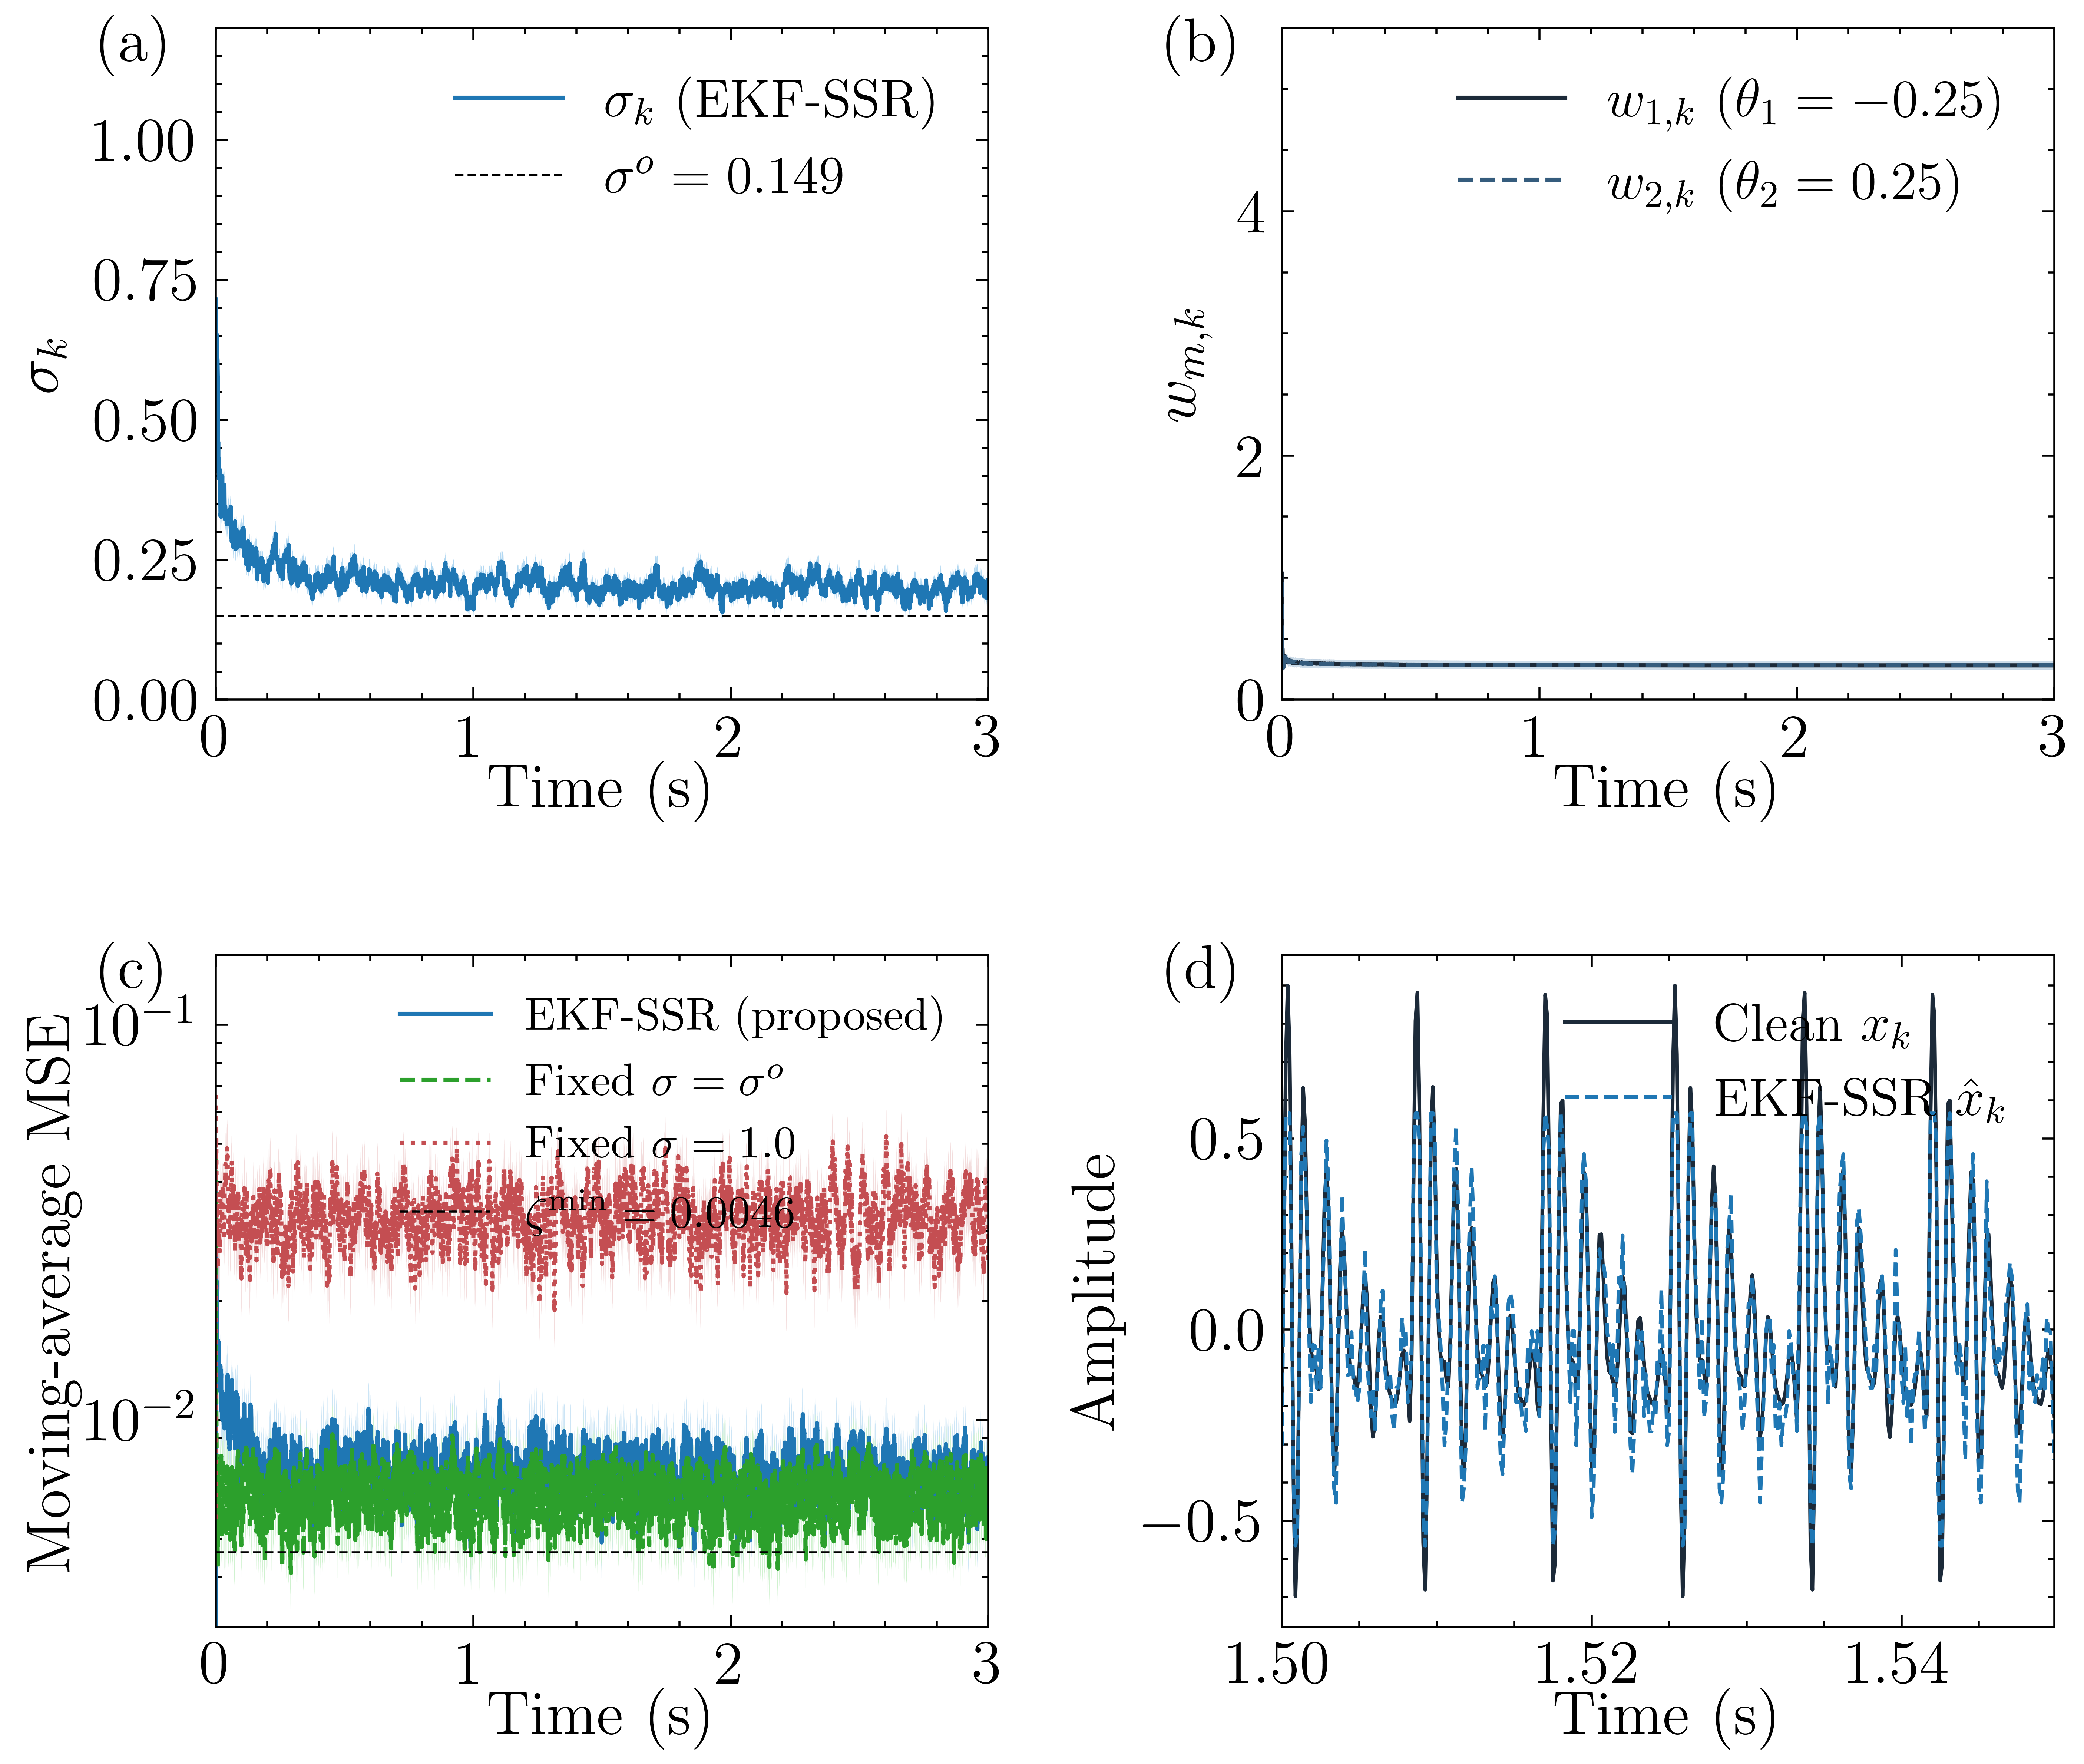


Grouped SSR (N1=15,θ1=-0.25, N2=16,θ2=0.25), speech /a/, fs=8000 Hz
Method                                sigma        MSE  SNR(dB)
-----------------------------------------------------------------
Theory (Gaussian f_x)                0.1494    0.00462    12.36
Theory (KDE f_x)                     0.1446    0.00504    11.99
Grouped EKF-SSR (proposed)           0.2021    0.00727    10.40
Grouped fixed sigma=sigma*           0.1446    0.00644    10.93
Grouped fixed sigma=1.0              1.0000    0.03321     3.80
SNR gain (EKF-SSR vs fixed 1.0) : +6.60 dB
SNR gap  (EKF-SSR vs KDE opt)   :  -0.53 dB


In [4]:
# ════════════════════════════════════════════════════════
# 5.  绘图（参照 Fig7 风格）
# ════════════════════════════════════════════════════════
from matplotlib.ticker import ScalarFormatter

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size'       : 15,
    'axes.labelsize'  : 15,
    'legend.fontsize' : 13,
})

def lighten_color(color, amount=0.7):
    import matplotlib.colors as mc, colorsys
    try: c = mc.cnames[color]
    except: c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount*(1-c[1]), c[2])

# ── 配色定义 ──────────────────────────────────────────
# Panel (a) sigma_k：蓝色系
c_sigma   = '#1f77b4'
lc_sigma  = lighten_color(c_sigma, amount=0.30)

# Panel (b) w1_k, w2_k：灰蓝色系（参照 Panel 3 reference）
c_w1  = '#1c2a39';  lc_w1 = lighten_color(c_w1, amount=0.22)
c_w2  = '#355c7d';  lc_w2 = lighten_color(c_w2, amount=0.22)

# Panel (c) MSE：硬朗对比色（参照 Panel 2 reference）
c_ekf_m  = '#1f77b4';  lc_ekf_m = lighten_color(c_ekf_m, amount=0.20)
c_fix_m  = '#2ca02c';  lc_fix_m = lighten_color(c_fix_m, amount=0.20)
c_sub_m  = '#c44e52';  lc_sub_m = lighten_color(c_sub_m, amount=0.20)

# Panel (d) 波形：黑 + 蓝虚线
c_clean  = '#1c2a39'
c_recon  = '#1f77b4'

labels_txt = ['(a)', '(b)', '(c)', '(d)']

# ── 创建图形 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
plt.subplots_adjust(hspace=0.38, wspace=0.38)
axes = axes.flatten()

t_sec = t_arr   # 时间轴（秒）

# ── (a) sigma_k 收敛轨迹 ──────────────────────────────
ax = axes[0]
# 单次轨迹无std，用轻微阴影表示区间感
ax.fill_between(t_sec,
                np.maximum(sig_hist * 0.92, 0),
                sig_hist * 1.08,
                color=lc_sigma, edgecolor='none')
ax.plot(t_sec, sig_hist,
        color=c_sigma, lw=1.0,
        label=r'$\sigma_k$ (EKF-SSR)')
ax.axhline(sigma_th_G, color='k', lw=0.5, ls=(0, (4, 2)),
           label=rf'$\sigma^o = {sigma_th_G:.3f}$')
ax.set_xlim([0, duration])
ax.set_ylim([0, 1.2])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$\sigma_k$', labelpad=6)
ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax.text(-0.15, 1.02, labels_txt[0], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (b) w1_k, w2_k 收敛轨迹 ──────────────────────────
ax = axes[1]
ax.fill_between(t_sec,
                np.maximum(w1_hist * 0.88, 0),
                w1_hist * 1.12,
                color=lc_w1, edgecolor='none')
ax.plot(t_sec, w1_hist,
        color=c_w1, lw=1.0,
        label=rf'$w_{{1,k}}$ ($\theta_1={theta1}$)')

ax.fill_between(t_sec,
                np.maximum(w2_hist * 0.88, 0),
                w2_hist * 1.12,
                color=lc_w2, edgecolor='none')
ax.plot(t_sec, w2_hist,
        color=c_w2, lw=1.0, ls='--',
        label=rf'$w_{{2,k}}$ ($\theta_2={theta2}$)')

ax.set_xlim([0, duration])
ax.set_ylim([0, 5.5])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'$w_{m,k}$', labelpad=6)
ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax.text(-0.15, 1.02, labels_txt[1], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (c) 滑动平均 MSE（log 轴，三种方法对比）─────────
ax = axes[2]

# EKF-SSR
ax.fill_between(t_sec,
                np.maximum(mse_ekf_ma * 0.80, 1e-5),
                mse_ekf_ma * 1.20,
                color=lc_ekf_m, edgecolor='none')
ax.plot(t_sec, mse_ekf_ma,
        color=c_ekf_m, lw=1.0,
        label='EKF-SSR (proposed)')

# Fixed sigma = sigma^o
ax.fill_between(t_sec,
                np.maximum(mse_fix_ma * 0.80, 1e-5),
                mse_fix_ma * 1.20,
                color=lc_fix_m, edgecolor='none')
ax.plot(t_sec, mse_fix_ma,
        color=c_fix_m, lw=1.0, ls='--',
        label=r'Fixed $\sigma = \sigma^o$')

# Fixed sigma = 1.0
ax.fill_between(t_sec,
                np.maximum(mse_sub_ma * 0.80, 1e-5),
                mse_sub_ma * 1.20,
                color=lc_sub_m, edgecolor='none')
ax.plot(t_sec, mse_sub_ma,
        color=c_sub_m, lw=1.0, ls=':',
        label=r'Fixed $\sigma = 1.0$')

# 理论下界
ax.axhline(mse_th_G, color='k', lw=0.5, ls=(0, (4, 2)),
           label=rf'$\zeta^{{\rm min}} = {mse_th_G:.4f}$')

ax.set_yscale('log')
ax.set_xlim([0, duration])
ax.set_ylim([3e-3, 1.5e-1])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'Moving-average MSE', labelpad=1)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.text(-0.15, 1.02, labels_txt[2], transform=ax.transAxes,
        fontsize=15, va='top')

# ── (d) 50 ms 波形重建（稳态段）─────────────────────
ax = axes[3]
k0 = steady
k1 = k0 + int(0.05 * fs)   # 50 ms
t_show = t_sec[k0:k1]

ax.plot(t_show, speech[k0:k1],
        color=c_clean, lw=0.9,
        label=r'Clean $x_k$')
ax.plot(t_show, xhat_ekf[k0:k1],
        color=c_recon, lw=0.9, ls='--',
        label=r'EKF-SSR $\hat{x}_k$')

ax.set_xlim([t_show[0], t_show[-1]])
ax.set_xlabel(r'Time (s)', labelpad=-2)
ax.set_ylabel(r'Amplitude', labelpad=4)
ax.legend(loc='upper right', fontsize=13, framealpha=0.9)
ax.text(-0.15, 1.02, labels_txt[3], transform=ax.transAxes,
        fontsize=15, va='top')

# ── 保存 ─────────────────────────────────────────────
fig.savefig('speech_ssr_grouped.eps',
            format='eps', dpi=800, bbox_inches='tight')
fig.savefig('speech_ssr_grouped.pdf',
            bbox_inches='tight')
fig.savefig('speech_ssr_grouped.png',
            dpi=800, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════
# 6.  稳态汇总表
# ════════════════════════════════════════════════════════
print("\n" + "="*65)
print(f"Grouped SSR (N1={N1},θ1={theta1}, N2={N2},θ2={theta2}), "
      f"speech /a/, fs={fs} Hz")
print("="*65)
print(f"{'Method':<35} {'sigma':>7} {'MSE':>10} {'SNR(dB)':>8}")
print("-"*65)
for name, sig, mse, snr in [
    ("Theory (Gaussian f_x)",         sigma_th_G, mse_th_G, snr_th_G),
    ("Theory (KDE f_x)",              sigma_th_E, mse_th_E, snr_th_E),
    ("Grouped EKF-SSR (proposed)",    sig_ss,     mse_ekf_ss, snr_ekf),
    ("Grouped fixed sigma=sigma*",    sigma_th_E, mse_fix_ss, snr_fix),
    ("Grouped fixed sigma=1.0",       1.0,        mse_sub_ss, snr_sub),
]:
    print(f"{name:<35} {sig:>7.4f} {mse:>10.5f} {snr:>8.2f}")
print("="*65)
print(f"SNR gain (EKF-SSR vs fixed 1.0) : +{snr_ekf-snr_sub:.2f} dB")
print(f"SNR gap  (EKF-SSR vs KDE opt)   :  {snr_ekf-snr_fix:+.2f} dB")
